# bosperrus on a Visium HD tissue microarray (TMA)

This tutorial runs bosperrus' two spatial-transcriptomics entry points directly on a Space Ranger
output folder (10x Visium HD, Human Breast Cancer TMA demo, 8 µm bins):

1. **Analysis buffer** -- `load_filtered` + `identify_analysis_buffer_from_filtered`: how far into the
   tissue counts are depressed near the tissue border, fitted per TMA core.
2. **RNA diffusion outside the tissue** -- `quantify_diffusion_from_raw`: how many counts land outside an
   image-only tissue mask, and how quickly they decay with distance from it.

Both work the same way on a STOmics/Stereo-seq SAW run folder with `technology="stereo-seq"`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bosperrus

# Space Ranger's binned_outputs/ folder of the 10x Visium HD Human Breast Cancer TMA demo dataset
PATH = "/home/woody/iwbn/iwbn007h/visium_hd_demo_data/Visium_HD_11mm_Human_Breast_Cancer_TMA/binned_outputs"
TECHNOLOGY, RESOLUTION_UM = "visium_hd", 8

## 1. Analysis buffer per TMA core

`load_filtered` reads Space Ranger's tissue-filtered matrix (`square_008um/filtered_feature_bc_matrix.h5`, i.e.
the bins Space Ranger calls `in_tissue`) and returns a genes-free AnnData with per-bin total counts and grid
indices -- enough for the border analysis, and small even for large samples.

In [2]:
adata = bosperrus.load_filtered(PATH, TECHNOLOGY, RESOLUTION_UM)
adata

AnnData object with n_obs × n_vars = 415161 × 0
    obs: 'array_row', 'array_col', 'n_counts'
    uns: 'bosperrus'
    obsm: 'spatial'

`identify_analysis_buffer_from_filtered` then

- takes the bins with `n_counts > 0` as tissue, filling small enclosed empty holes (up to `max_hole_area_um2`,
  default 1024 µm² = 16 bins) so that single empty bins inside the tissue don't count as border,
- splits the tissue into connected components -- here the individual TMA cores -- and drops components with
  `<= min_component_size` bins,
- fits a piecewise-linear "border depression + plateau" model against a constant (AIC) of counts vs. distance to
  the core's own border, per core. A core gets a buffer only if the piecewise fit wins **and** counts rise into
  the tissue (`border_effect=True`); the buffer is every bin closer to the border than the fitted elbow.

In [3]:
bosperrus.identify_analysis_buffer_from_filtered(adata, min_component_size=1000)

fit = adata.uns["analysis_buffer_fit"]
summary = pd.DataFrame({
    label: {"n_bins": info["n_spots"], "best_fit": info["best_fit_type"], "border_effect": info["border_effect"],
            "elbow_um": info["elbow_um"],
            "pct_in_buffer": 100 * adata.obs["analysis_buffer"][adata.obs["components"] == label].mean()}
    for label, info in fit["per_component"].items()
}).T
print(f"{len(summary)} cores; {summary['border_effect'].sum()} with a border effect; "
      f"{fit['n_filled_hole_bins']} zero-count bins inside small holes kept as tissue")
summary.head(10)

36 cores; 32 with a border effect; 4466 zero-count bins inside small holes kept as tissue


,n_bins,best_fit,border_effect,elbow_um,pct_in_buffer
0,17353,Piecewise Linear Fit,True,115.513571,41.86596
1,14335,Piecewise Linear Fit,True,16.0,14.475061
2,13618,Piecewise Linear Fit,True,18.468822,10.478778
3,13177,Piecewise Linear Fit,True,45.547175,20.649617
4,12963,Piecewise Linear Fit,True,100.978185,38.355319
5,12836,Piecewise Linear Fit,True,27.881423,12.402618
6,12698,Piecewise Linear Fit,True,25.715011,12.419279
7,12582,Piecewise Linear Fit,True,28.057771,12.494039
8,12573,Piecewise Linear Fit,True,44.851162,19.32713
9,12521,Piecewise Linear Fit,True,24.0,11.396853


`plot_border_effect` shows each core's counts vs. distance to its border with the fitted model on top. Cores
without a border effect (constant fit, or a piecewise fit that *falls* into the tissue) are drawn too -- check
`border_effect` in the table above for which ones get a buffer.

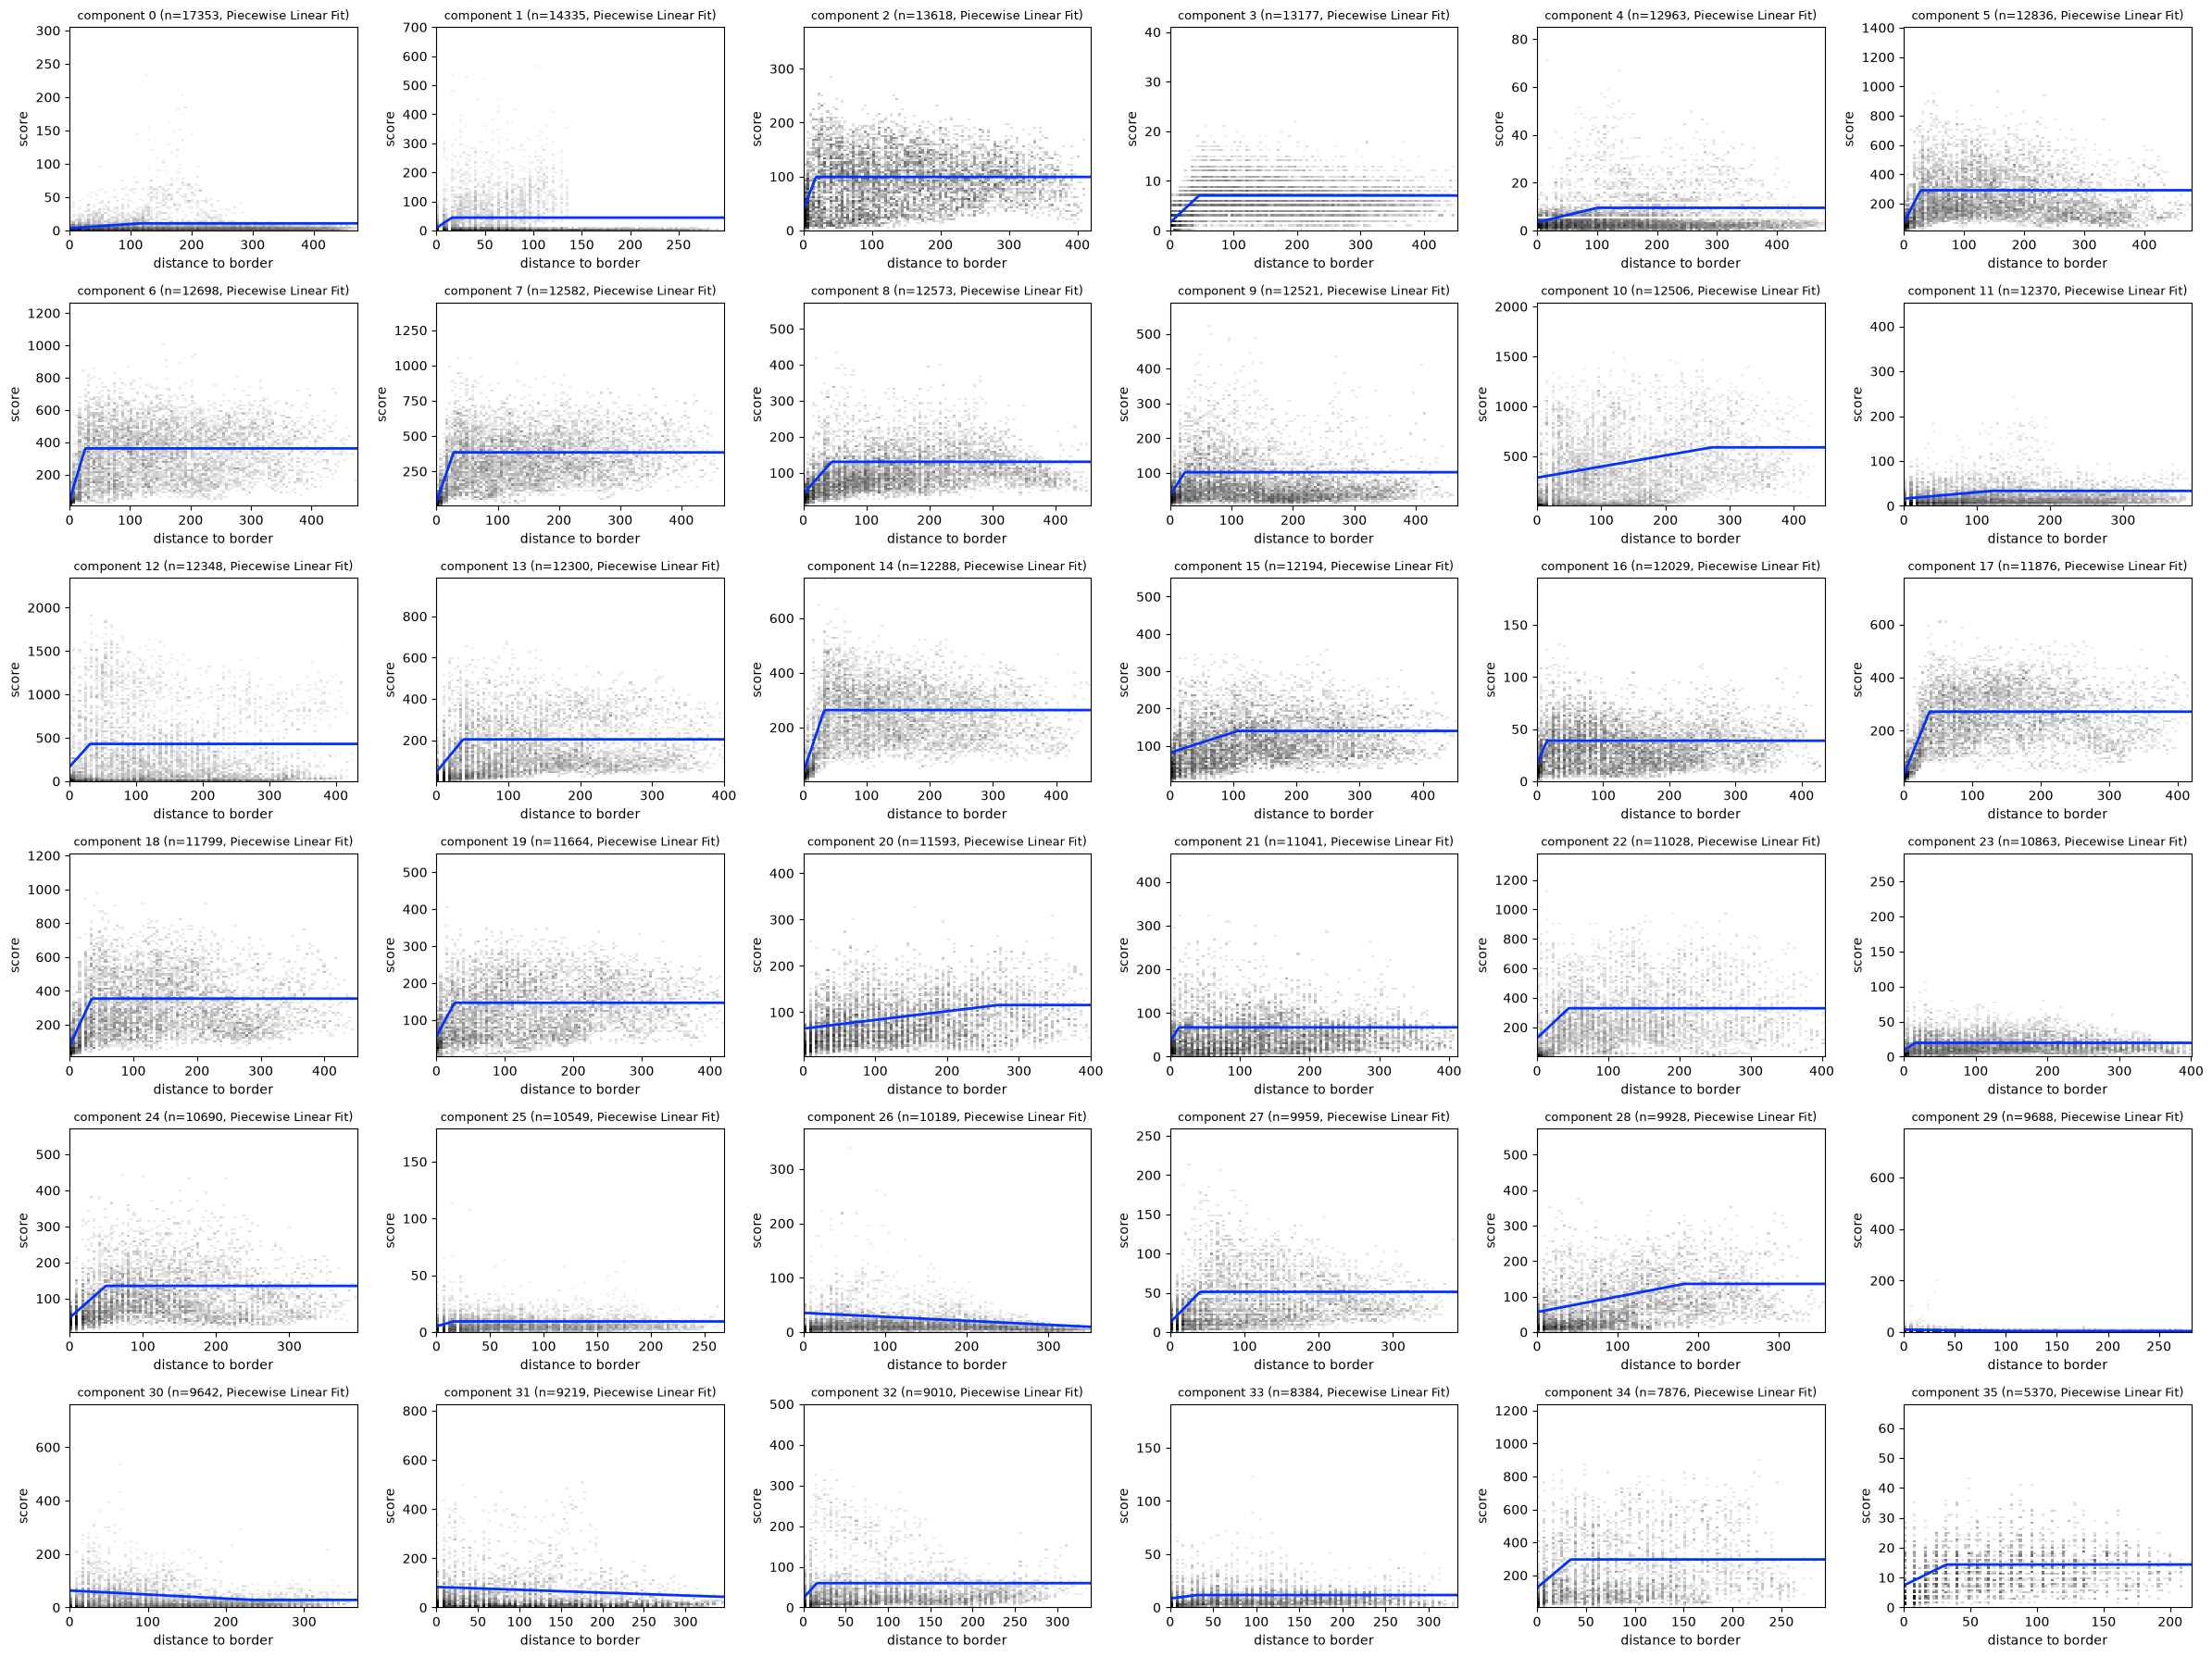

In [4]:
fig = bosperrus.plot_border_effect(adata, score="n_counts", ncols=6)
plt.show()

### Where are the cores, borders and buffers?

`obs` now holds `components`, `border`, `distance_to_border` (µm) and `analysis_buffer`. Plotted at each bin's
position in the full-resolution image (`obsm["spatial"]`), so the orientation matches the H&E below:

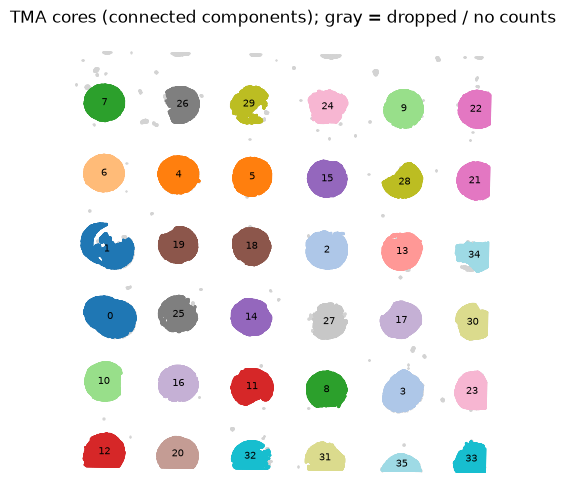

In [5]:
obs = adata.obs
x, y = adata.obsm["spatial"][:, 0], adata.obsm["spatial"][:, 1]  # full-resolution image pixels
kept = (obs["components"] >= 0).to_numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[~kept], y[~kept], s=0.2, color="lightgray", rasterized=True)
ax.scatter(x[kept], y[kept], s=0.2, c=obs["components"][kept], cmap="tab20", rasterized=True)
for label in summary.index:
    member = (obs["components"] == label).to_numpy()
    ax.text(x[member].mean(), y[member].mean(), str(label), fontsize=7, ha="center", va="center")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
ax.set_title("TMA cores (connected components); gray = dropped / no counts")
plt.show()

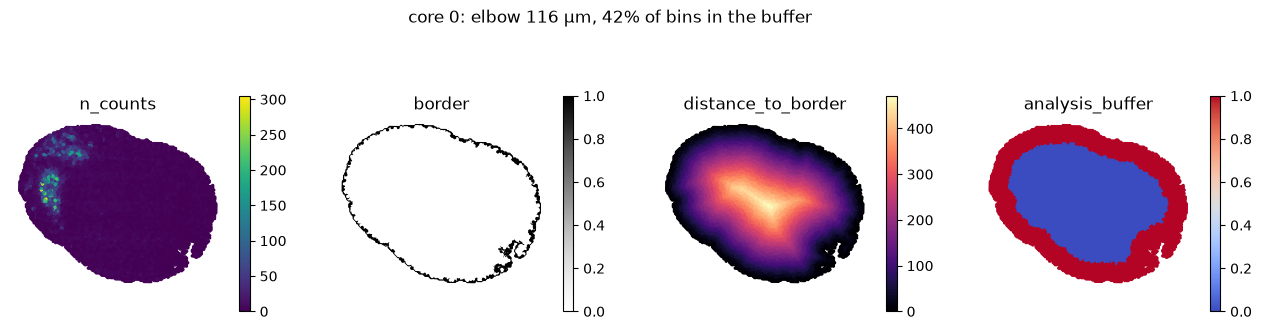

In [6]:
# one core in detail: the largest core with a border effect
core = summary[summary["border_effect"].astype(bool)]["n_bins"].astype(int).idxmax()
member = (obs["components"] == core).to_numpy()
c = obs[member]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, cmap) in zip(axs, [("n_counts", "viridis"), ("border", "Greys"), ("distance_to_border", "magma"), ("analysis_buffer", "coolwarm")]):
    sca = ax.scatter(x[member], y[member], c=c[col].astype(float), s=2, cmap=cmap, rasterized=True)
    fig.colorbar(sca, ax=ax, shrink=0.7)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off"); ax.set_title(col)
fig.suptitle(f"core {core}: elbow {fit['per_component'][core]['elbow_um']:.0f} µm, "
             f"{summary.loc[core, 'pct_in_buffer']:.0f}% of bins in the buffer")
plt.show()

## 2. RNA diffusion outside the tissue

`quantify_diffusion_from_raw` works on the **raw** (whole capture area, unfiltered) matrix instead:

- it segments Space Ranger's own hires H&E image into an image-only tissue mask (`segment_tissue_from_rgb`;
  tune via `mask_kwargs`),
- gives every raw bin of the capture area -- zero-count bins included -- its distance (µm) outside that mask,
- fits an exponential decay `a * exp(-b d)` against a constant (AIC) to the per-bin counts outside the mask.

It returns the percentage of all counts outside the mask, `alpha` (the fitted amplitude per µm²), `beta` (the
decay rate, 1/µm) and the decay length `1 / beta`. With `return_data=True` it also returns the image, mask and
per-bin data behind the fit. Unlike the analysis buffer, this is one pooled fit for the whole sample.

In [7]:
result, data = bosperrus.quantify_diffusion_from_raw(PATH, TECHNOLOGY, RESOLUTION_UM, return_data=True)
{k: result[k] for k in ["best_fit_type", "perc_counts_outside", "alpha", "beta", "decay_length_um", "n_bins_total", "n_bins_outside"]}

/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:143: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(close_radius))
/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:144: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_holes(mask, area_threshold=min_hole_area)
/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:145: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0

{'best_fit_type': 'Exponential Decay Fit',
 'perc_counts_outside': 7.601562200970772,
 'alpha': 0.7484986946072829,
 'beta': 0.033594557861562506,
 'decay_length_um': 29.766726031068217,
 'n_bins_total': 1907161,
 'n_bins_outside': 1523639}

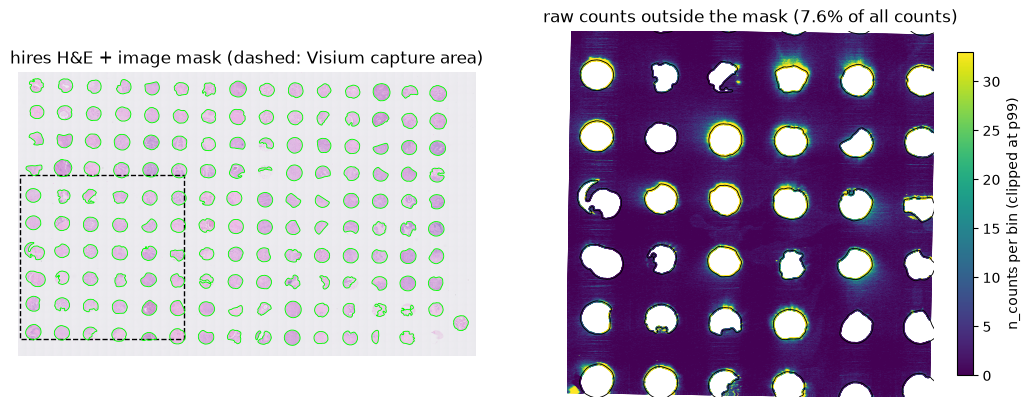

In [8]:
# left: the hires H&E with the image mask and the capture area; right: raw counts per 8um bin outside the mask,
# zoomed to the capture area (only the cores inside it were sequenced)
mask, image = data["mask"], data["image"]
outside = data["distance_um"] > 0
r0, r1 = data["mask_row"].min(), data["mask_row"].max()
c0, c1 = data["mask_col"].min(), data["mask_col"].max()

fig, axs = plt.subplots(1, 2, figsize=(13, 6))
axs[0].imshow(image)
axs[0].contour(mask.astype(float), levels=[0.5], colors=["lime"], linewidths=0.6)
axs[0].add_patch(plt.Rectangle((c0, r0), c1 - c0, r1 - r0, fill=False, edgecolor="black", lw=1, ls="--"))
axs[0].set_xlim(0, image.shape[1]); axs[0].set_ylim(image.shape[0], 0)
axs[0].set_title("hires H&E + image mask (dashed: Visium capture area)")
sca = axs[1].scatter(data["mask_col"][outside], data["mask_row"][outside], c=data["n_counts"][outside], s=1,
                     cmap="viridis", vmax=np.percentile(data["n_counts"][outside], 99), rasterized=True)
axs[1].contour(mask.astype(float), levels=[0.5], colors=["black"], linewidths=0.6)
axs[1].set_xlim(c0, c1); axs[1].set_ylim(r1, r0)
fig.colorbar(sca, ax=axs[1], shrink=0.7, label="n_counts per bin (clipped at p99)")
axs[1].set_title(f"raw counts outside the mask ({result['perc_counts_outside']:.1f}% of all counts)")
for ax in axs:
    ax.set_aspect("equal"); ax.axis("off")
plt.show()

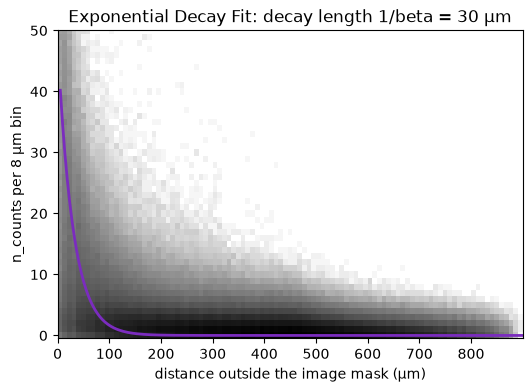

In [9]:
# the fit behind alpha/beta: counts per bin vs. distance outside the mask, with the fitted decay
best = data["best_fit"]
fig, ax = plt.subplots(figsize=(6, 4))
y_max = np.percentile(data["n_counts"][outside], 99.5)
bins = [np.linspace(0, data["distance_um"][outside].max(), 100), np.arange(-0.5, y_max + 1.5, 1.0)]  # 1-count bins
bosperrus.plot_fit(ax, data["distance_um"][outside], data["n_counts"][outside], best.predict, bins=bins,
                   line_kwargs={"color": bosperrus.FIT_PALETTE.get(best.name, "red")})
ax.set_xlabel("distance outside the image mask (µm)")
ax.set_ylabel("n_counts per 8 µm bin")
ax.set_ylim(-0.5, y_max)
ax.set_title(f"{best.name}: decay length 1/beta = {result['decay_length_um']:.0f} µm")
plt.show()

## 3. Analysis buffer with the image mask as tissue footprint

Section 1 starts from Space Ranger's own tissue call (`in_tissue`), which is not purely image-derived. To use
the image-only mask from section 2 instead, take the **raw** bins inside the mask (distance to the mask = 0) from
`quantify_diffusion_from_raw(..., return_data=True)` and hand them to `identify_analysis_buffer_from_filtered`
in place of `load_filtered`'s output. Everything downstream -- `n_counts > 0`, hole filling, components, the
elbow fit -- is unchanged. (Raw and filtered bins sit on the same 8 µm grid, so `array_row`/`array_col` match.)

In [10]:
import anndata

inside = data["distance_um"] == 0  # raw bins inside the image mask
obs_im = pd.DataFrame({
    "array_row": data["array_row"][inside],
    "array_col": data["array_col"][inside],
    "n_counts": data["n_counts"][inside],
})
obs_im.index = obs_im["array_row"].astype(str) + "_" + obs_im["array_col"].astype(str)
adata_im = anndata.AnnData(obs=obs_im)
adata_im.uns["bosperrus"] = {"technology": TECHNOLOGY, "bin_size_um": RESOLUTION_UM}  # distances in um

bosperrus.identify_analysis_buffer_from_filtered(adata_im, min_component_size=1000)

In [11]:
def per_core(a):
    per = a.uns["analysis_buffer_fit"]["per_component"]
    return pd.DataFrame({
        label: {"border_effect": info["border_effect"], "elbow_um": info["elbow_um"],
                "pct_in_buffer": 100 * a.obs["analysis_buffer"][a.obs["components"] == label].mean()}
        for label, info in per.items()
    }).T

for name, a in [("in_tissue (section 1)", adata), ("image mask", adata_im)]:
    t = per_core(a)
    print(f"{name:22s}: {a.n_obs:7,} input bins, {len(t)} cores, {int(t['border_effect'].sum())} with a border effect, "
          f"median elbow {pd.to_numeric(t['elbow_um']).median():.0f} um, median {pd.to_numeric(t['pct_in_buffer']).median():.0f}% in buffer")

in_tissue (section 1) : 415,161 input bins, 36 cores, 32 with a border effect, median elbow 34 um, median 17% in buffer
image mask            : 383,522 input bins, 36 cores, 29 with a border effect, median elbow 31 um, median 10% in buffer


Component labels are assigned per run (largest component first), so the same core can carry a different label
in the two runs -- compare per-core results by position, not by label.

**Variant -- intersect instead of replace:** to keep only the filtered (`in_tissue`) bins that also lie inside the
image mask, select them by grid position and rerun the analysis on that subset:

```python
in_mask = pd.MultiIndex.from_arrays([data["array_row"][inside], data["array_col"][inside]])
keep = pd.MultiIndex.from_arrays([adata.obs["array_row"], adata.obs["array_col"]]).isin(in_mask)
adata_both = bosperrus.load_filtered(PATH, TECHNOLOGY, RESOLUTION_UM)[keep].copy()
bosperrus.identify_analysis_buffer_from_filtered(adata_both, min_component_size=1000)
```